# 🧹 Step 1 — Data Preprocessing

**Protein Function Prediction Using Genomic Language Model (ESM-2)**

This notebook loads the CSV datasets collected by `collect_data.py`, filters GO terms,
creates multi-label encodings, and splits into train/val/test sets.

---

### Prerequisites
Run `python collect_data.py` first to generate 5 CSV datasets in `data/raw/`

### Input Datasets
| File | Description |
|------|-------------|
| `data/raw/proteins.csv` | Master protein table |
| `data/raw/go_annotations.csv` | Protein → GO mappings |
| `data/raw/protein_go_summary.csv` | Per-protein GO summary |
| `data/raw/go_term_statistics.csv` | GO term frequencies |
| `data/raw/sequence_statistics.csv` | Sequence composition |

### Output
| File | Description |
|------|-------------|
| `data/processed/protein_data.csv` | Cleaned protein-level DataFrame |
| `data/processed/label_binarizer.pkl` | Fitted MultiLabelBinarizer |
| `data/processed/labels_{split}.npy` | Binary label matrices |
| `data/processed/sequences_{split}.npy` | Sequence arrays per split |
| `results/plots/preprocessing_summary.png` | Distribution plots |

## 1.1 — Configuration & Setup

In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.model_selection import train_test_split

# ─── Configuration ───
PROJECT_ROOT = os.path.dirname(os.path.abspath('__file__'))
RAW_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
PLOTS_DIR = os.path.join(PROJECT_ROOT, 'results', 'plots')

# Preprocessing parameters
MIN_GO_TERM_COUNT = 20     # Minimum annotations per GO term to keep
MAX_GO_TERMS = 50          # Maximum number of GO classes
TEST_SIZE = 0.10
VAL_SIZE = 0.10
RANDOM_STATE = 42

# Create directories
for d in [PROCESSED_DIR, PLOTS_DIR]:
    os.makedirs(d, exist_ok=True)

np.random.seed(RANDOM_STATE)
plt.style.use('dark_background')

ACCENT_COLORS = ['#00D4FF', '#FF6B6B', '#4ECDC4', '#FFE66D',
                 '#A855F7', '#F97316', '#06B6D4', '#EC4899']

print(f'📂 Raw data dir    : {RAW_DIR}')
print(f'📂 Output dir      : {PROCESSED_DIR}')
print(f'🔢 Min GO count    : {MIN_GO_TERM_COUNT}')
print(f'🔢 Max GO terms    : {MAX_GO_TERMS}')

📂 Raw data dir    : C:\Users\Abhishek\.gemini\antigravity\scratch\Work_PLM\Work_PLM\protein_function_prediction\data\raw
📂 Output dir      : C:\Users\Abhishek\.gemini\antigravity\scratch\Work_PLM\Work_PLM\protein_function_prediction\data\processed
🔢 Min GO count    : 20
🔢 Max GO terms    : 50


## 1.2 — Load Raw CSV Datasets

Load all 5 CSV datasets produced by `collect_data.py`

In [2]:
# Load all 5 CSV datasets
proteins_df = pd.read_csv(os.path.join(RAW_DIR, 'proteins.csv'))
go_df = pd.read_csv(os.path.join(RAW_DIR, 'go_annotations.csv'))
go_summary_df = pd.read_csv(os.path.join(RAW_DIR, 'protein_go_summary.csv'))
go_stats_df = pd.read_csv(os.path.join(RAW_DIR, 'go_term_statistics.csv'))
seq_stats_df = pd.read_csv(os.path.join(RAW_DIR, 'sequence_statistics.csv'))

print('📋 Loaded CSV Datasets:')
print(f'  1. proteins.csv           : {len(proteins_df):,} rows')
print(f'  2. go_annotations.csv     : {len(go_df):,} rows')
print(f'  3. protein_go_summary.csv : {len(go_summary_df):,} rows')
print(f'  4. go_term_statistics.csv : {len(go_stats_df):,} rows')
print(f'  5. sequence_statistics.csv: {len(seq_stats_df):,} rows')
print(f'\n🧬 Unique proteins: {go_df["protein_id"].nunique():,}')
print(f'🏷️  Unique GO terms: {go_df["go_id"].nunique():,}')

📋 Loaded CSV Datasets:
  1. proteins.csv           : 2,000 rows
  2. go_annotations.csv     : 34,553 rows
  3. protein_go_summary.csv : 2,000 rows
  4. go_term_statistics.csv : 8,504 rows
  5. sequence_statistics.csv: 2,000 rows

🧬 Unique proteins: 2,000
🏷️  Unique GO terms: 8,504


In [3]:
# Preview each dataset
print('\n─── proteins.csv (head) ───')
display(proteins_df.head())
print('\n─── go_annotations.csv (head) ───')
display(go_df.head())
print('\n─── go_term_statistics.csv (top 10) ───')
display(go_stats_df.head(10))
print('\n─── sequence_statistics.csv (head) ───')
display(seq_stats_df.head())


─── proteins.csv (head) ───


,protein_id,protein_name,organism,sequence,length
0,A0A1B0GTW7,Ciliated left-right organizer metallopeptidase...,Homo sapiens (Human),MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788
1,A0PK11,Clarin-2,Homo sapiens (Human),MPGWFKKAWYGLASLLSFSSFILIIVALVVPHWLSGKILCQTGVDL...,232
2,A1A4S6,Rho GTPase-activating protein 10 (GTPase regul...,Homo sapiens (Human),MGLQPLEFSDCYLDSPWFRERIRAHEAELERTNKFIKELIKDGKNL...,786
3,A1A519,Protein FAM170A (Zinc finger domain-containing...,Homo sapiens (Human),MKRRQKRKHLENEESQETAEKGGGMSKSQEDALQPGSTRVAKGWSQ...,330
4,A1L190,Synaptonemal complex central element protein 3...,Homo sapiens (Human),MDDADPEERNYDNMLKMLSDLNKDLEKLLEEMEKISVQATWMAYDM...,88



─── go_annotations.csv (head) ───


,protein_id,go_id,sequence,length
0,A0A1B0GTW7,GO:0004222,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788
1,A0A1B0GTW7,GO:0005737,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788
2,A0A1B0GTW7,GO:0006508,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788
3,A0A1B0GTW7,GO:0007155,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788
4,A0A1B0GTW7,GO:0008233,MLLLLLLLLLLPPLVLRVAASRCLHDETQKSVSLLRPPFSQLPSKS...,788



─── go_term_statistics.csv (top 10) ───


,go_id,protein_count,annotation_count,avg_protein_length,min_protein_length,max_protein_length,pct_of_proteins
0,GO:0005829,691,691,450.4,54,995,34.55
1,GO:0005634,632,632,434.5,54,993,31.60
2,GO:0005886,591,591,467.2,66,988,29.55
3,GO:0005737,579,579,442.7,54,998,28.95
4,GO:0005654,498,498,448.9,76,993,24.90
5,GO:0016020,337,337,480.9,65,993,16.85
6,GO:0070062,302,302,400.3,66,986,15.10
7,GO:0042802,247,247,443.0,68,993,12.35
8,GO:0005576,223,223,363.5,54,981,11.15
9,GO:0005739,206,206,391.0,51,978,10.30



─── sequence_statistics.csv (head) ───


,protein_id,length,molecular_weight_approx,unique_amino_acids,most_common_aa,pct_hydrophobic,pct_charged,pct_polar
0,A0A1B0GTW7,788,86680,20,L,42.13,20.05,28.81
1,A0PK11,232,25520,20,L,56.47,16.38,19.83
2,A1A4S6,786,86460,20,L,39.57,29.77,25.70
3,A1A519,330,36300,20,E,28.48,32.42,32.42
4,A1L190,88,9680,19,E,39.77,38.64,21.59


## 1.3 — Filter GO Terms by Frequency

In [4]:
# Use go_term_statistics.csv for filtering
frequent_go = go_stats_df[
    go_stats_df['protein_count'] >= MIN_GO_TERM_COUNT
].head(MAX_GO_TERMS)

selected_go_terms = set(frequent_go['go_id'].tolist())
print(f'✅ Selected {len(selected_go_terms)} GO terms (min count >= {MIN_GO_TERM_COUNT})')
print(f'   Count range: {frequent_go["protein_count"].min()} – {frequent_go["protein_count"].max()}')

filtered_df = go_df[go_df['go_id'].isin(selected_go_terms)].copy()
print(f'\n📊 Filtered: {len(filtered_df):,} annotations, {filtered_df["protein_id"].nunique():,} proteins')

✅ Selected 50 GO terms (min count >= 20)
   Count range: 60 – 691

📊 Filtered: 8,387 annotations, 1,963 proteins


## 1.4 — Create Protein-Level Dataset & Multi-Label Binarization

In [5]:
protein_df = filtered_df.groupby('protein_id').agg({
    'go_id': list,
    'sequence': 'first',
    'length': 'first',
}).reset_index()
protein_df.columns = ['protein_id', 'go_terms', 'sequence', 'length']
protein_df['num_go_terms'] = protein_df['go_terms'].apply(len)
protein_df['length'] = protein_df['length'].astype(int)

# Multi-label binarization
mlb = MultiLabelBinarizer()
labels = mlb.fit_transform(protein_df['go_terms'])

print(f'📊 Protein dataset : {len(protein_df)} proteins')
print(f'📊 Label shape     : {labels.shape}')
print(f'🏷️  GO classes      : {len(mlb.classes_)}')
print(f'📊 Labels/sample   : mean={labels.sum(axis=1).mean():.2f}')

# Save binarizer
binarizer_path = os.path.join(PROCESSED_DIR, 'label_binarizer.pkl')
with open(binarizer_path, 'wb') as f:
    pickle.dump(mlb, f)
print(f'💾 Label binarizer → {binarizer_path}')

📊 Protein dataset : 1963 proteins
📊 Label shape     : (1963, 50)
🏷️  GO classes      : 50
📊 Labels/sample   : mean=4.27
💾 Label binarizer → C:\Users\Abhishek\.gemini\antigravity\scratch\Work_PLM\Work_PLM\protein_function_prediction\data\processed\label_binarizer.pkl


## 1.5 — Train / Validation / Test Split

In [6]:
protein_ids = protein_df['protein_id'].values
sequences = protein_df['sequence'].values

# Two-stage split
idx_trainval, idx_test = train_test_split(
    np.arange(len(protein_df)), test_size=TEST_SIZE, random_state=RANDOM_STATE
)
relative_val = VAL_SIZE / (1 - TEST_SIZE)
idx_train, idx_val = train_test_split(
    idx_trainval, test_size=relative_val, random_state=RANDOM_STATE
)

print(f'📊 Train : {len(idx_train)} ({len(idx_train)/len(protein_df)*100:.1f}%)')
print(f'📊 Val   : {len(idx_val)} ({len(idx_val)/len(protein_df)*100:.1f}%)')
print(f'📊 Test  : {len(idx_test)} ({len(idx_test)/len(protein_df)*100:.1f}%)')

# Save all splits
def save_np(arr, name):
    path = os.path.join(PROCESSED_DIR, name)
    np.save(path, arr)
    return path

for split, idx in [('train', idx_train), ('val', idx_val), ('test', idx_test)]:
    save_np(labels[idx], f'labels_{split}.npy')
    save_np(protein_ids[idx], f'ids_{split}.npy')
    save_np(sequences[idx], f'sequences_{split}.npy')

protein_df.to_csv(os.path.join(PROCESSED_DIR, 'protein_data.csv'), index=False)
print('\n💾 All processed data saved!')

📊 Train : 1569 (79.9%)
📊 Val   : 197 (10.0%)
📊 Test  : 197 (10.0%)

💾 All processed data saved!


## 1.6 — Preprocessing Visualizations

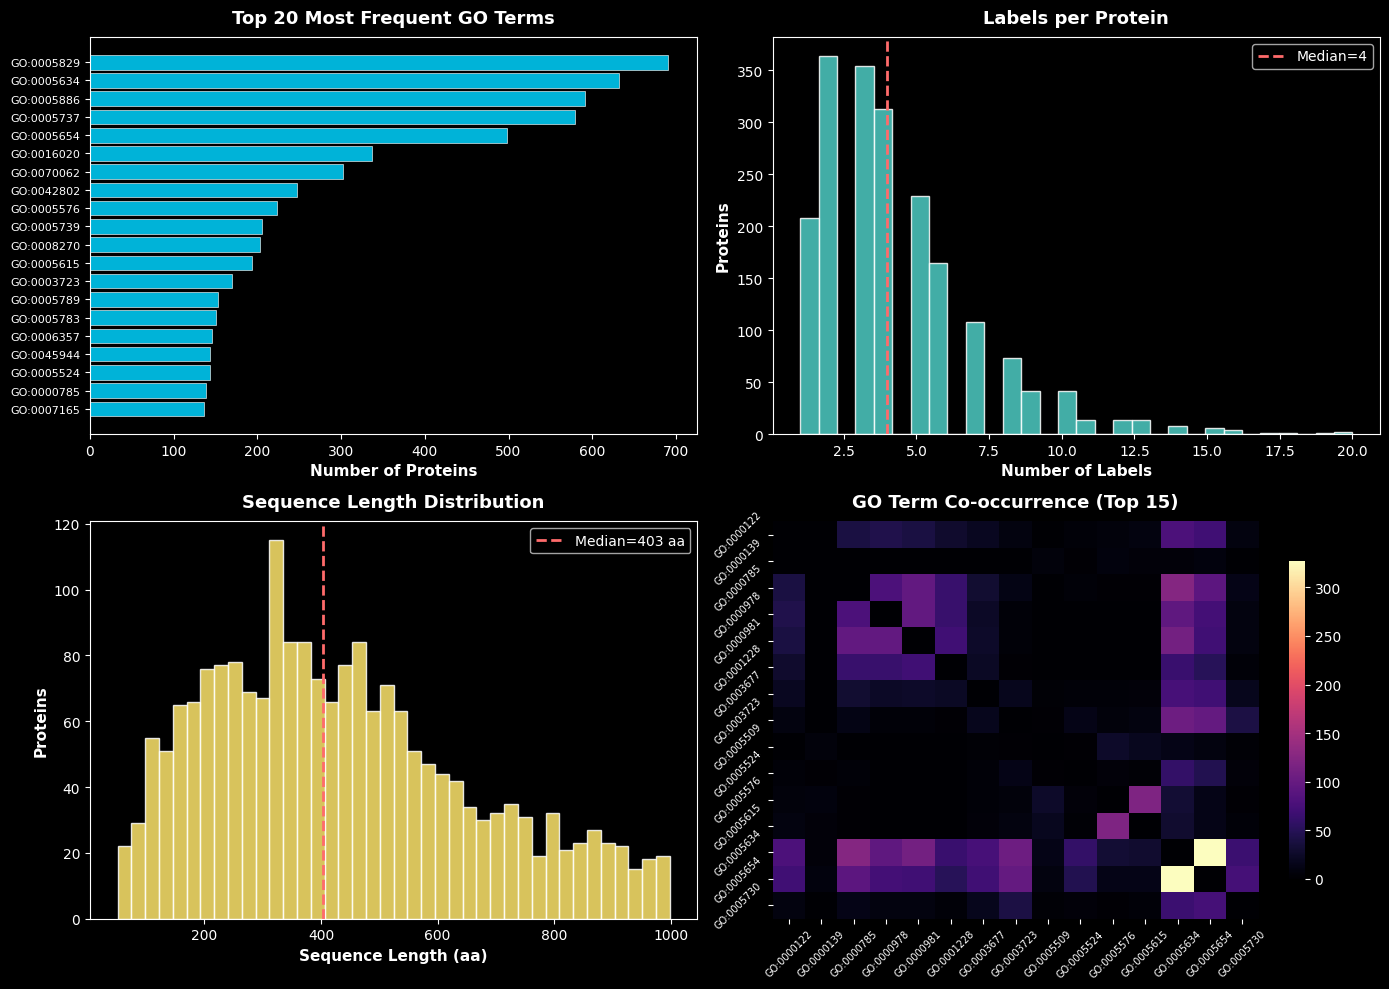

✅ Preprocessing visualizations saved!


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
c = ACCENT_COLORS

# 1. Top GO terms
ax = axes[0, 0]
top = frequent_go.head(20)
ax.barh(range(len(top)), top['protein_count'].values,
        color=c[0], alpha=0.85, edgecolor='white', linewidth=0.5)
ax.set_yticks(range(len(top)))
ax.set_yticklabels(top['go_id'].values, fontsize=8)
ax.set_xlabel('Number of Proteins', fontsize=11, fontweight='bold')
ax.set_title('Top 20 Most Frequent GO Terms', fontsize=13, fontweight='bold', pad=10)
ax.invert_yaxis()

# 2. Labels per sample
ax = axes[0, 1]
lps = labels.sum(axis=1)
ax.hist(lps, bins=30, color=c[2], alpha=0.85, edgecolor='white')
ax.axvline(np.median(lps), color=c[1], linestyle='--', lw=2, label=f'Median={np.median(lps):.0f}')
ax.set_xlabel('Number of Labels', fontsize=11, fontweight='bold')
ax.set_ylabel('Proteins', fontsize=11, fontweight='bold')
ax.set_title('Labels per Protein', fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10)

# 3. Sequence length distribution (from sequence_statistics.csv)
ax = axes[1, 0]
ax.hist(seq_stats_df['length'].values, bins=40, color=c[3], alpha=0.85, edgecolor='white')
ax.axvline(seq_stats_df['length'].median(), color=c[1], linestyle='--', lw=2,
           label=f'Median={seq_stats_df["length"].median():.0f} aa')
ax.set_xlabel('Sequence Length (aa)', fontsize=11, fontweight='bold')
ax.set_ylabel('Proteins', fontsize=11, fontweight='bold')
ax.set_title('Sequence Length Distribution', fontsize=13, fontweight='bold', pad=10)
ax.legend(fontsize=10)

# 4. Label co-occurrence heatmap
ax = axes[1, 1]
n_top = min(15, labels.shape[1])
cooc = np.dot(labels[:, :n_top].T, labels[:, :n_top])
np.fill_diagonal(cooc, 0)
sns.heatmap(cooc, ax=ax, cmap='magma', xticklabels=mlb.classes_[:n_top],
            yticklabels=mlb.classes_[:n_top], cbar_kws={'shrink': 0.8})
ax.set_title('GO Term Co-occurrence (Top 15)', fontsize=13, fontweight='bold', pad=10)
ax.tick_params(axis='both', labelsize=7, labelrotation=45)

plt.tight_layout()
plt.savefig(os.path.join(PLOTS_DIR, 'preprocessing_summary.png'), dpi=300, bbox_inches='tight')
plt.show()
print('✅ Preprocessing visualizations saved!')

---
### ✅ Preprocessing Complete!
**Next →** Open `02_feature_extraction.ipynb`